# Sistema de clasificación de imágenes

In [ ]:
import os
import zipfile
import shutil
import random
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPool2D,
    Dense,
    GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


## Descomprimir los Gatos y Perros

In [3]:
import zipfile
from pathlib import Path

zip_path = Path("../data/raw/dogs-vs-cats.zip")
extract_path = Path("../data/raw")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Zip descomprimido correctamente")


Zip descomprimido correctamente


In [4]:
print(os.listdir("../data/raw/dogs-vs-cats"))


['.DS_Store', 'dataset_split', 'sampleSubmission.csv', 'train']


In [5]:
original_train_dir = Path("../data/raw/dogs-vs-cats/train")
base_dir = Path("../data/raw/dogs-vs-cats/dataset_split")

train_dir = base_dir / "train"
val_dir = base_dir / "validation"

# Crear carpetas
for folder in [
    train_dir / "cats",
    train_dir / "dogs",
    val_dir / "cats",
    val_dir / "dogs"
]:
    folder.mkdir(parents=True, exist_ok=True)

# Listar imágenes
images = list(original_train_dir.glob("*.jpg"))

random.seed(42)
random.shuffle(images)

split_idx = int(len(images) * 0.8)
train_images = images[:split_idx]
val_images = images[split_idx:]

# Copiar imágenes
for img_path in train_images:
    if "cat" in img_path.name:
        shutil.copy(img_path, train_dir / "cats")
    else:
        shutil.copy(img_path, train_dir / "dogs")

for img_path in val_images:
    if "cat" in img_path.name:
        shutil.copy(img_path, val_dir / "cats")
    else:
        shutil.copy(img_path, val_dir / "dogs")

print("Dataset dividido correctamente")


Dataset dividido correctamente


In [6]:
print(os.listdir("../data/raw/dogs-vs-cats/dataset_split"))

['validation', 'train']


## Generadores (versión estable)

para no matar RAM:

> - IMG_SIZE = 128
>
> - BATCH_SIZE = 8

In [7]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 8

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

trdata = train_datagen.flow_from_directory(
    "../data/raw/dogs-vs-cats/dataset_split/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

tsdata = val_datagen.flow_from_directory(
    "../data/raw/dogs-vs-cats/dataset_split/validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)


Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


## Modelo CNN

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, GlobalAveragePooling2D

model = Sequential()

model.add(Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(64, (3,3), padding="same", activation="relu"))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model.add(MaxPool2D((2,2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation="relu"))
model.add(Dense(2, activation="softmax"))

model.summary()


/home/vscode/.local/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-25 02:16:37.815083: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,018 (429.76 KB)

 Trainable params: 110,018 (429.76 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"])

In [10]:
history = model.fit(
    trdata,
    validation_data=tsdata,
    epochs=3)

Epoch 1/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 223s 88ms/step - accuracy: 0.5896 - loss: 0.6632 - val_accuracy: 0.6146 - val_loss: 0.6450
Epoch 2/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 258s 87ms/step - accuracy: 0.6734 - loss: 0.5991 - val_accuracy: 0.6836 - val_loss: 0.5846
Epoch 3/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 214s 86ms/step - accuracy: 0.7200 - loss: 0.5517 - val_accuracy: 0.7316 - val_loss: 0.5293


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

trdata = train_datagen.flow_from_directory(
    "../data/raw/dogs-vs-cats/dataset_split/train",
    target_size=(128,128),
    batch_size=8,
    class_mode="categorical"
)

tsdata = val_datagen.flow_from_directory(
    "../data/raw/dogs-vs-cats/dataset_split/validation",
    target_size=(128,128),
    batch_size=8,
    class_mode="categorical"
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [12]:

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


In [13]:
history = model.fit(
    trdata,
    validation_data=tsdata,
    epochs=10,
    callbacks=[earlystop]
)


Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 250s 100ms/step - accuracy: 0.7267 - loss: 0.5409 - val_accuracy: 0.6948 - val_loss: 0.5785
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 248s 99ms/step - accuracy: 0.7562 - loss: 0.5026 - val_accuracy: 0.7900 - val_loss: 0.4490
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 252s 101ms/step - accuracy: 0.7871 - loss: 0.4542 - val_accuracy: 0.8190 - val_loss: 0.4013
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 253s 101ms/step - accuracy: 0.8077 - loss: 0.4155 - val_accuracy: 0.8336 - val_loss: 0.3709
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 246s 98ms/step - accuracy: 0.8306 - loss: 0.3795 - val_accuracy: 0.7828 - val_loss: 0.4809
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 257s 96ms/step - accuracy: 0.8432 - loss: 0.3525 - val_accuracy: 0.8472 - val_loss: 0.3560
Epoch 7/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 302s 121ms/step - accuracy: 0.8504 - loss: 0.3391 - val_accuracy: 0.8792 - val_loss: 0.2904
Epoch 8/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 248s 99ms/step - accura

Guardo el Modelo

In [16]:
model.save("../models/dogs_vs_cats_final.keras")

/home/vscode/.local/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


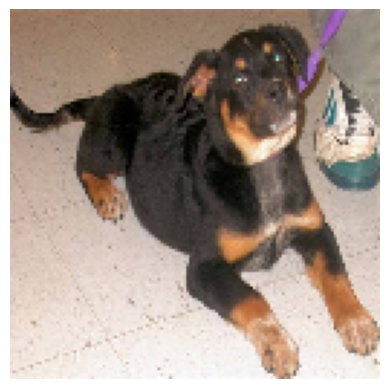

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
dog
Vector softmax: [[0.17112975 0.82887024]]


In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

saved_model = load_model("../models/dogs_vs_cats_final.keras")
img_path = "../data/raw/dogs-vs-cats/dataset_split/validation/dogs/" + \
           os.listdir("../data/raw/dogs-vs-cats/dataset_split/validation/dogs")[0]
img = image.load_img(img_path, target_size=(128, 128))
img = np.asarray(img)
plt.imshow(img)
plt.axis("off")
plt.show()
img = img / 255.0
img = np.expand_dims(img, axis=0)
output = saved_model.predict(img)
if output[0][0] > output[0][1]:
    print("cat")
else:
    print("dog")

print("Vector softmax:", output)